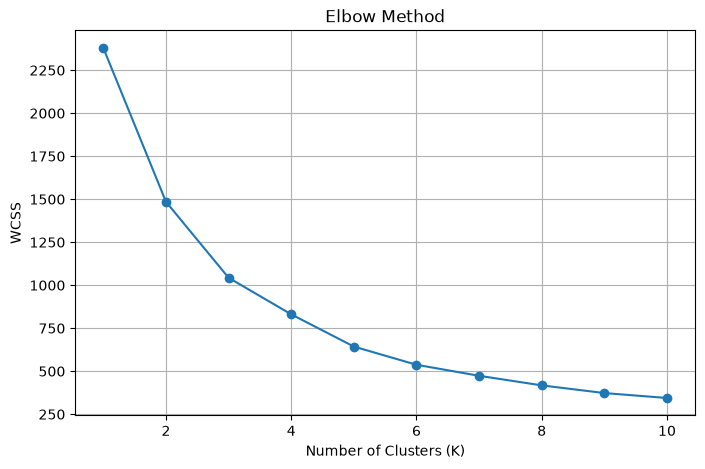

Cluster
2    463
1    267
0     63
Name: count, dtype: int64


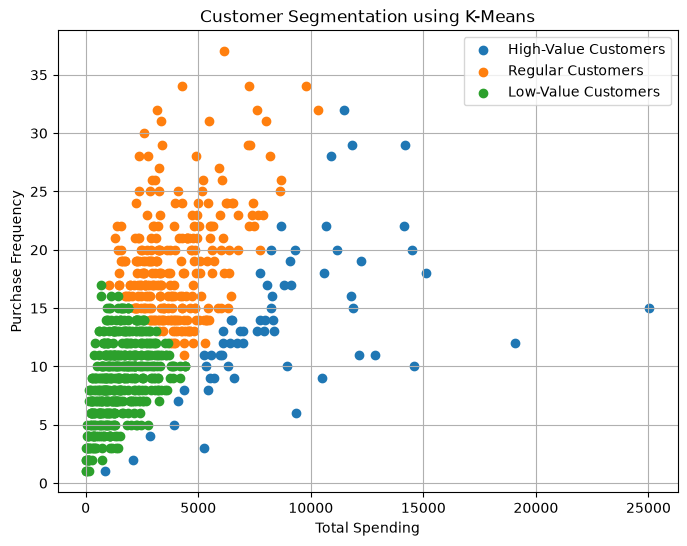

Customer segmentation completed successfully.


In [29]:
# ==========================================
# Customer Segmentation using K-Means
# Milestone 2 - Day 2
# ==========================================

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ------------------------------------------
# Load Dataset
# ------------------------------------------

df = pd.read_csv("../../week1/preprocessing/cleaned_dataset.csv")

# View first five rows
df.head()

# Display column names
df.columns

# ------------------------------------------
# Create Customer-Level Features
# ------------------------------------------

customer_df = df.groupby("Customer ID").agg(
    TotalSpending=("Total amount", "sum"),
    PurchaseFrequency=("Order ID", "count"),
    AverageOrderValue=("Total amount", "mean")
).reset_index()

customer_df.head()

# ------------------------------------------
# Feature Selection
# ------------------------------------------

features = customer_df[
    [
        "TotalSpending",
        "PurchaseFrequency",
        "AverageOrderValue"
    ]
]

# ------------------------------------------
# Feature Scaling
# ------------------------------------------

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# ------------------------------------------
# Elbow Method
# ------------------------------------------

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.grid(True)
plt.show()

# ------------------------------------------
# Train Final K-Means Model
# ------------------------------------------

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

customer_df["Cluster"] = kmeans.fit_predict(scaled_features)

# View clustered data

customer_df.head()

# Number of customers in each cluster

print(customer_df["Cluster"].value_counts())

# ------------------------------------------
# Cluster Visualization
# ------------------------------------------

cluster_names = {
    0: "High-Value Customers",
    1: "Regular Customers",
    2: "Low-Value Customers"
}

plt.figure(figsize=(8,6))

for cluster in sorted(customer_df["Cluster"].unique()):

    data = customer_df[customer_df["Cluster"] == cluster]

    plt.scatter(
        data["TotalSpending"],
        data["PurchaseFrequency"],
        label=cluster_names[cluster]
    )

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Total Spending")
plt.ylabel("Purchase Frequency")

plt.legend()
plt.grid(True)

plt.show()

# ------------------------------------------
# Save Customer Segments
# ------------------------------------------

customer_df.to_csv(
    "customer_segments.csv",
    index=False
)

# ------------------------------------------
# Save Trained Model
# ------------------------------------------

joblib.dump(
    kmeans,
    "kmeans_customer_model.pkl"
)

print("Customer segmentation completed successfully.")